In [ ]:
!pip install -q kaggle

import os

os.environ['KAGGLE_USERNAME'] = 'himajachaluvadi'
os.environ['KAGGLE_KEY'] = 'KGAT_e0d4b880e92a4cb6dfff3ca75770a3d3'

In [ ]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset
!unzip -q new-plant-diseases-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.69G/2.70G [00:26<00:00, 245MB/s]
100% 2.70G/2.70G [00:26<00:00, 109MB/s]


In [ ]:
!kaggle datasets download -d dasa7753912/new-paddy-doctor-paddy-disease-classification
!unzip -q new-paddy-doctor-paddy-disease-classification.zip

Dataset URL: https://www.kaggle.com/datasets/dasa7753912/new-paddy-doctor-paddy-disease-classification
License(s): unknown
 99% 2.16G/2.17G [00:15<00:00, 133MB/s]
100% 2.17G/2.17G [00:17<00:00, 131MB/s]


In [ ]:
import os
import shutil
import random

os.makedirs("dataset/train/rice", exist_ok=True)
os.makedirs("dataset/train/non_rice", exist_ok=True)
os.makedirs("dataset/validation/rice", exist_ok=True)
os.makedirs("dataset/validation/non_rice", exist_ok=True)

In [ ]:
source_dir = "/content/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train"

all_images = []

for folder in os.listdir(source_dir):

    if "rice" in folder.lower():
        continue

    folder_path = os.path.join(source_dir, folder)

    for img in os.listdir(folder_path):

        if img.endswith(".jpg") or img.endswith(".png"):
            img_path = os.path.join(folder_path, img)
            all_images.append(img_path)

random.shuffle(all_images)

non_rice_train = all_images[:2000]
non_rice_val = all_images[2000:2400]

for img in non_rice_train:
    shutil.copy(img, "dataset/train/non_rice")

for img in non_rice_val:
    shutil.copy(img, "dataset/validation/non_rice")

In [ ]:
rice_source = "/content/paddy-disease-classification/train_images"

rice_images = []

for folder in os.listdir(rice_source):

    folder_path = os.path.join(rice_source, folder)

    if os.path.isdir(folder_path):

        for img in os.listdir(folder_path):

            if img.endswith(".jpg") or img.endswith(".png"):

                img_path = os.path.join(folder_path, img)
                rice_images.append(img_path)

random.shuffle(rice_images)


rice_train = rice_images[:2000]
rice_val = rice_images[2000:2400]

for img in rice_train:
    shutil.copy(img, "dataset/train/rice")

for img in rice_val:
    shutil.copy(img, "dataset/validation/rice")

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 224
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=35,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.6,1.4],
    fill_mode="nearest"
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    "dataset/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_data = val_gen.flow_from_directory(
    "dataset/validation",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 3898 images belonging to 2 classes.
Found 791 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
# for layer in base_model.layers[-20:]:
#     layer.trainable = True
for layer in base_model.layers:
    layer.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)

output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,394,020 (16.76 MB)

 Trainable params: 344,449 (1.31 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 121s 741ms/step - accuracy: 0.8605 - loss: 0.3524 - val_accuracy: 0.9975 - val_loss: 0.0228
Epoch 2/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 57s 465ms/step - accuracy: 0.9985 - loss: 0.0257 - val_accuracy: 0.9975 - val_loss: 0.0106
Epoch 3/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 55s 452ms/step - accuracy: 0.9999 - loss: 0.0091 - val_accuracy: 0.9975 - val_loss: 0.0079
Epoch 4/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 56s 462ms/step - accuracy: 0.9992 - loss: 0.0046 - val_accuracy: 0.9975 - val_loss: 0.0058
Epoch 5/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 55s 452ms/step - accuracy: 0.9989 - loss: 0.0045 - val_accuracy: 0.9987 - val_loss: 0.0050
Epoch 6/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 57s 464ms/step - accuracy: 0.9974 - loss: 0.0063 - val_accuracy: 0.9987 - val_loss: 0.0038
Epoch 7/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 55s 453ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9987 - val_loss: 0.0031
Epoch 8/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 56s 462ms/step - accuracy: 0.9998 - loss: 

In [ ]:
model.save("rice_vs_nonrice_model1.h5")

In [ ]:
print(train_data.class_indices)

{'non_rice': 0, 'rice': 1}


In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from google.colab import files

def predict_leaf(image_content):

    img = cv2.imdecode(np.frombuffer(image_content, np.uint8), cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224,224))

    img_for_pred = np.expand_dims(img, axis=0)
    img_for_pred = preprocess_input(img_for_pred)

    pred = model.predict(img_for_pred)[0][0]

    print("Model output:", pred)

    if pred > 0.5:
        label = "Rice Leaf 🌾"
        confidence = pred
    else:
        label = "Non Rice Leaf 🍃"
        confidence = 1 - pred

    plt.imshow(img) # Display the processed image directly
    plt.title(f"{label} ({confidence*100:.2f}%)")
    plt.axis("off")
    plt.show()

Saving coconutleaf3.jpeg to coconutleaf3 (1).jpeg
Uploaded file: coconutleaf3 (1).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Model output: 0.06730907


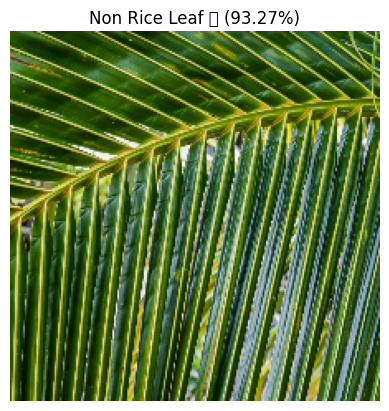

In [ ]:
uploaded = files.upload()
for name, content in uploaded.items():
    print(f"Uploaded file: {name}")
    predict_leaf(content)